In [1]:
import pandas as pd
import collections

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import scipy.sparse as sp
import scipy.io
import re

import seaborn as sns
import plotnine as p9
p9.theme_set(p9.theme_bw)

import umap
import scanpy as sc

def sparse_sum(x, dim):
    return np.squeeze(np.asarray(x.sum(dim)))

In [4]:
data_dir = Path("/gpfs/commons/groups/knowles_lab/data/sc/splitpool/microglia_less_mice/salmon_per_sublib")
adata = sc.read(data_dir / "t2g_permit_known.h5ad")
adata.obs.index = adata.obs.index.astype(str)
adata.var_names_make_unique() # surprised this wasn't done during preproc? 

/gpfs/commons/home/daknowles/.conda/envs/scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
/gpfs/commons/home/daknowles/.conda/envs/scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.


In [6]:
sc.pp.filter_cells(adata, min_counts = 3000)
sc.pp.filter_cells(adata, max_counts = 3e4)
sc.pp.filter_genes(adata, min_cells=5)
sc.pp.filter_genes(adata, min_counts = 1000)
adata.shape

(90736, 16331)

In [14]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata)

adata = adata[:, adata.var.highly_variable]
adata.shape

(90736, 2752)

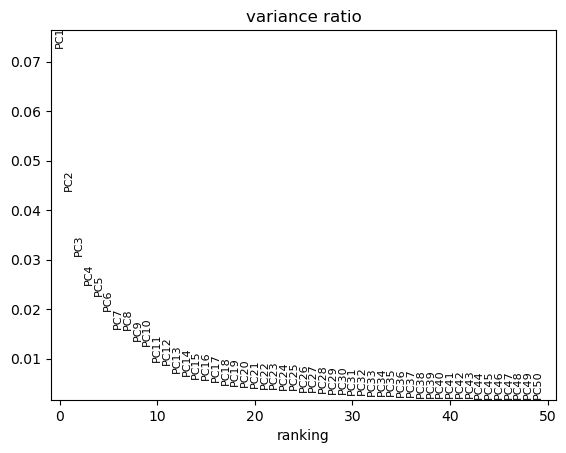

In [15]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=False, n_pcs=50)

/gpfs/commons/home/daknowles/.conda/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored


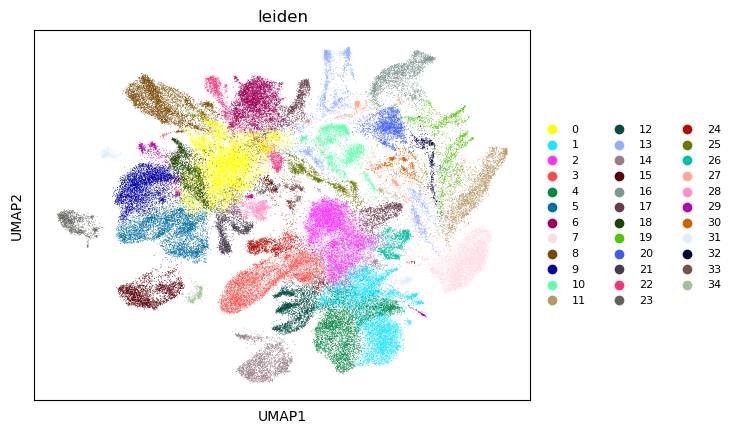

In [16]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)
sc.pl.umap(adata, color=['leiden'], legend_fontsize=8, save='_leiden')

/gpfs/commons/home/daknowles/.conda/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored


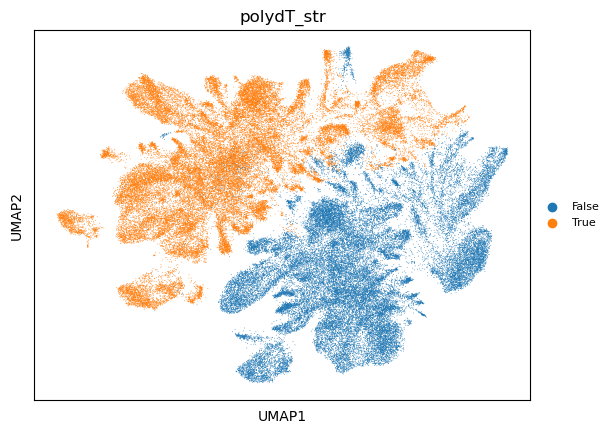

In [17]:
# large batch effect
adata.obs["polydT_str"] = adata.obs["polydT"].astype(str)
sc.pl.umap(adata, color=['polydT_str'], legend_fontsize=8)

/gpfs/commons/home/daknowles/.conda/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored


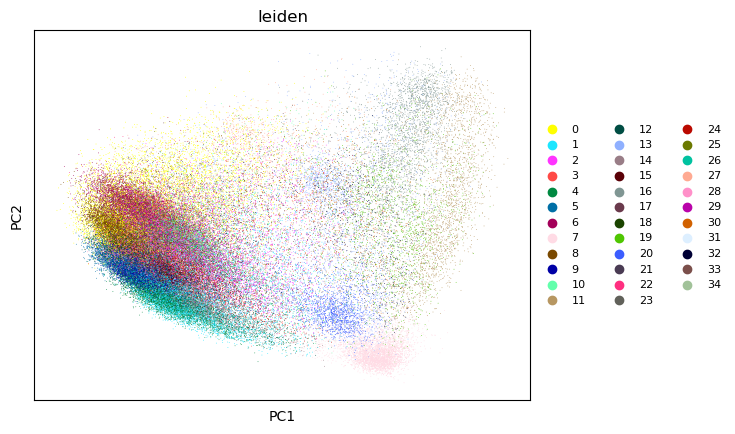

In [18]:
sc.pl.pca(adata, color=['leiden'], legend_fontsize=8)

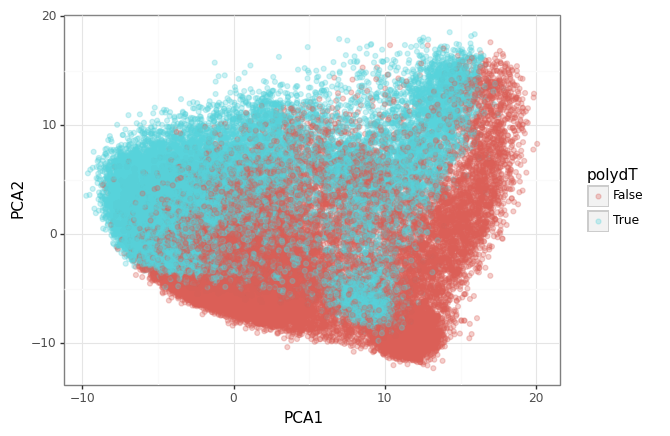

<ggplot: (8762394728839)>

In [20]:
pca_res = pd.DataFrame(adata.obsm["X_pca"][:,:2], columns = ["PCA1", "PCA2"])
pca_res["polydT"] = adata.obs.reset_index().polydT

p9.ggplot( pca_res, p9.aes( "PCA1", "PCA2", color = "polydT" )) + p9.geom_point(alpha = 0.3)

## Combined ranhex & polydT data

In [22]:
acomb = sc.read(data_dir / "t2g_permit_known_combined.h5ad") 
acomb.var_names_make_unique()
acomb.obs.index = acomb.obs.index.astype(str)

/gpfs/commons/home/daknowles/.conda/envs/scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
/gpfs/commons/home/daknowles/.conda/envs/scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.


In [23]:
acomb.shape

(109275, 21134)

In [25]:
sc.pp.filter_cells(acomb, min_counts = 3000)
sc.pp.filter_cells(acomb, max_counts = 3e4)
sc.pp.filter_genes(acomb, min_cells=5)
sc.pp.filter_genes(acomb, min_counts = 1000)
acomb.shape

(56949, 15472)

In [27]:
sc.pp.normalize_total(acomb, target_sum=1e4)
sc.pp.log1p(acomb)

sc.pp.highly_variable_genes(acomb)

acomb = acomb[:, acomb.var.highly_variable]
acomb.shape

(56949, 2734)

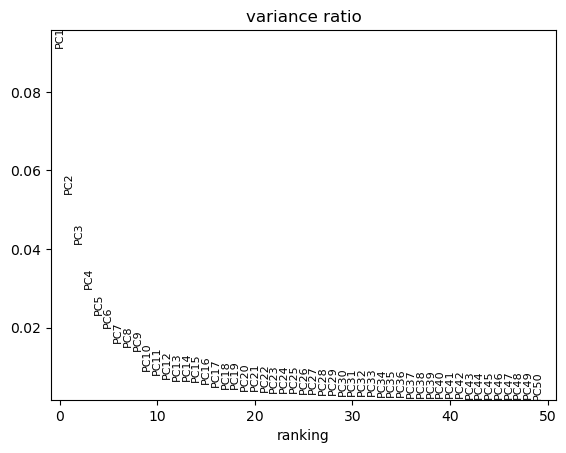

In [28]:
sc.tl.pca(acomb, svd_solver='arpack')
sc.pl.pca_variance_ratio(acomb, log=False, n_pcs=50)

/gpfs/commons/home/daknowles/.conda/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored


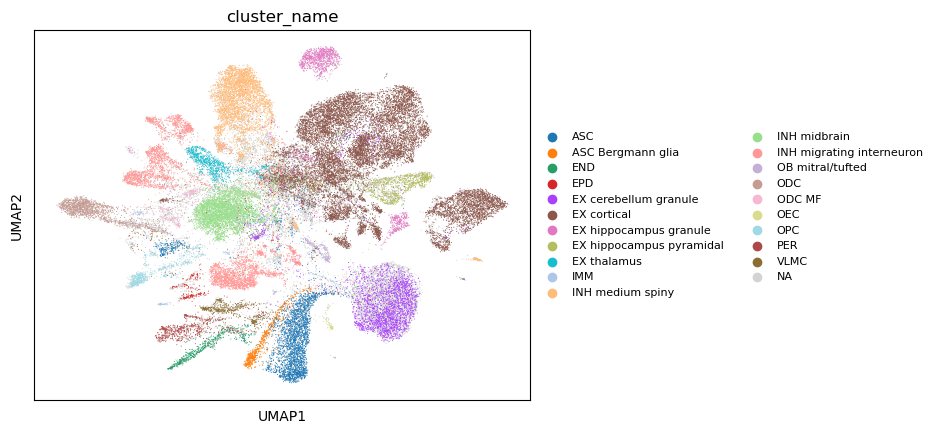

In [29]:
sc.pp.neighbors(acomb, n_neighbors=10, n_pcs=30)
sc.tl.umap(acomb)
sc.pl.umap(acomb, color=['cluster_name'], legend_fontsize=8)

In [30]:
# recluster
sc.tl.leiden(acomb, resolution=0.5)

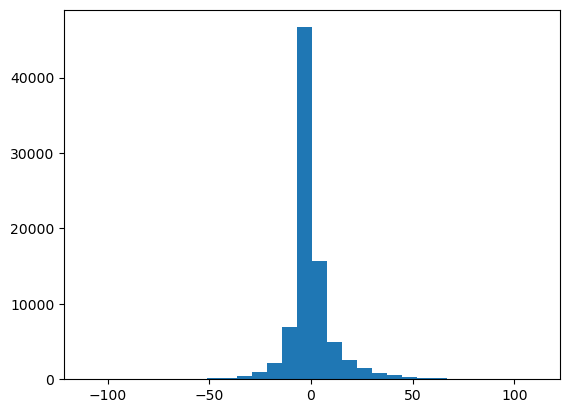

In [31]:
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
sc.tl.rank_genes_groups(acomb, 'leiden', method='wilcoxon') # this gives a bunch of warnings otherwise

marker_names = pd.DataFrame(acomb.uns['rank_genes_groups']['names'])

# scores are meant to be z-score-ish
marker_scores = pd.DataFrame(acomb.uns['rank_genes_groups']['scores'])
_ = plt.hist( np.array(marker_scores).flatten(), 30)

In [32]:
known_markers = pd.read_csv("PanglaoDB_markers_27_Mar_2020.tsv.gz", sep = "\t")
known_markers.rename(columns={'official gene symbol': 'gene'}, inplace=True)
known_markers.head()

,species,gene,cell type,nicknames,ubiquitousness index,product description,gene type,canonical marker,germ layer,organ,sensitivity_human,sensitivity_mouse,specificity_human,specificity_mouse
0,Mm Hs,CTRB1,Acinar cells,CTRB,0.017,chymotrypsinogen B1,protein-coding gene,1.0,Endoderm,Pancreas,1.000000,0.957143,0.000629,0.015920
1,Mm Hs,KLK1,Acinar cells,Klk6,0.013,kallikrein 1,protein-coding gene,1.0,Endoderm,Pancreas,0.833333,0.314286,0.005031,0.012826
2,Mm Hs,RBPJL,Acinar cells,RBP-L|SUHL|RBPSUHL,0.001,recombination signal binding protein for immun...,protein-coding gene,1.0,Endoderm,Pancreas,0.000000,0.000000,0.000000,0.000000
3,Mm Hs,PTF1A,Acinar cells,PTF1-p48|bHLHa29,0.001,pancreas associated transcription factor 1a,protein-coding gene,1.0,Endoderm,Pancreas,0.000000,0.157143,0.000629,0.000773
4,Mm,TRY4,Acinar cells,NaN,0.007,trypsin 4,protein coding gene,1.0,Endoderm,Pancreas,NaN,NaN,NaN,NaN


In [33]:
known_markers["canonical marker"].value_counts(dropna=False)

1.0    5422
NaN    2860
0.0       4
Name: canonical marker, dtype: int64

In [34]:
# filter for mouse markers
mouse_markers = known_markers[known_markers.species.str.contains("Mm")]
mouse_markers = mouse_markers.rename(columns={"official gene symbol" : "gene"})
mouse_markers["cell type"].value_counts().head(5)

Interneurons         220
Neurons              211
Endothelial cells    188
Fibroblasts          177
Germ cells           166
Name: cell type, dtype: int64

In [35]:
brain_markers = mouse_markers[ mouse_markers["organ"] == "Brain" ]
brain_markers["cell type"].value_counts().head(5)

Interneurons           220
Neurons                211
Oligodendrocytes        87
Cajal-Retzius cells     80
Microglia               79
Name: cell type, dtype: int64

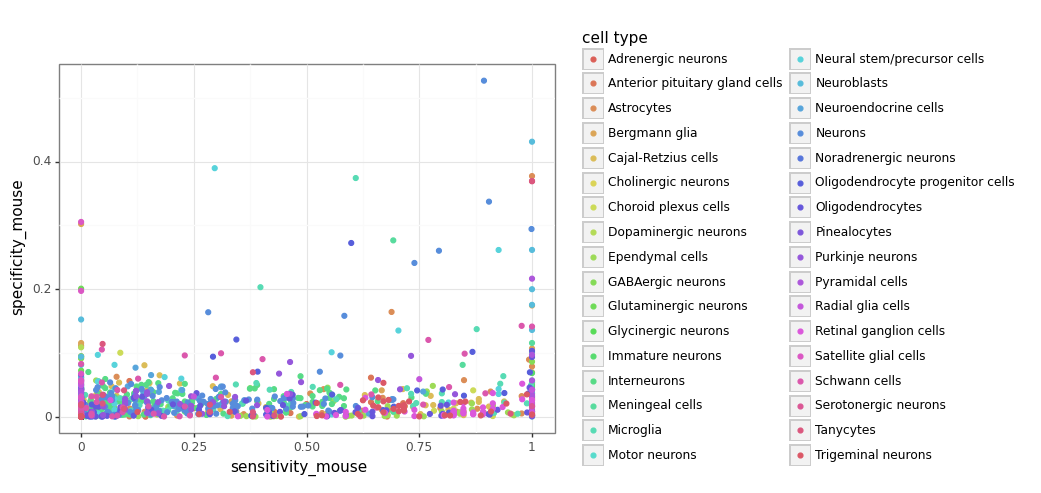

<ggplot: (8762395172849)>

In [36]:
p9.ggplot(brain_markers.fillna(0.), p9.aes(x="sensitivity_mouse", y="specificity_mouse", color = "cell type")) + p9.geom_point()

In [37]:
# filter for nonzero sensitivity and specificity 
brain_markers_filt = brain_markers[ (brain_markers.sensitivity_mouse>0.) & (brain_markers.specificity_mouse>0.) ]

In [38]:
# simple strategy for cell type assignment: average the enrichment z-scores for each possible cell type, and assign the one with the highest value
from collections import Counter
ct_counter = Counter() 
cell_type_anno = []
num_clusters = marker_names.shape[1]
for i in range(num_clusters):
    temp = pd.DataFrame({"gene":marker_names.iloc[:,i].str.upper(), "score":marker_scores.iloc[:,i]})
    temp = temp.merge(brain_markers_filt, on = "gene", how = "inner")
    res = temp.groupby('cell type').agg({'score': 'mean'}).sort_values(by='score', ascending=False)
    #print(res)
    ct = res.index[0]
    cell_type_anno.append(ct + ("" if (ct_counter[ct]==0) else "_%i"%(ct_counter[ct]+1))) # make names unique
    ct_counter[ct] += 1

In [39]:
acomb.obs.leiden = acomb.obs.leiden.cat.rename_categories(cell_type_anno)

<AxesSubplot: xlabel='leiden', ylabel='cluster_name'>

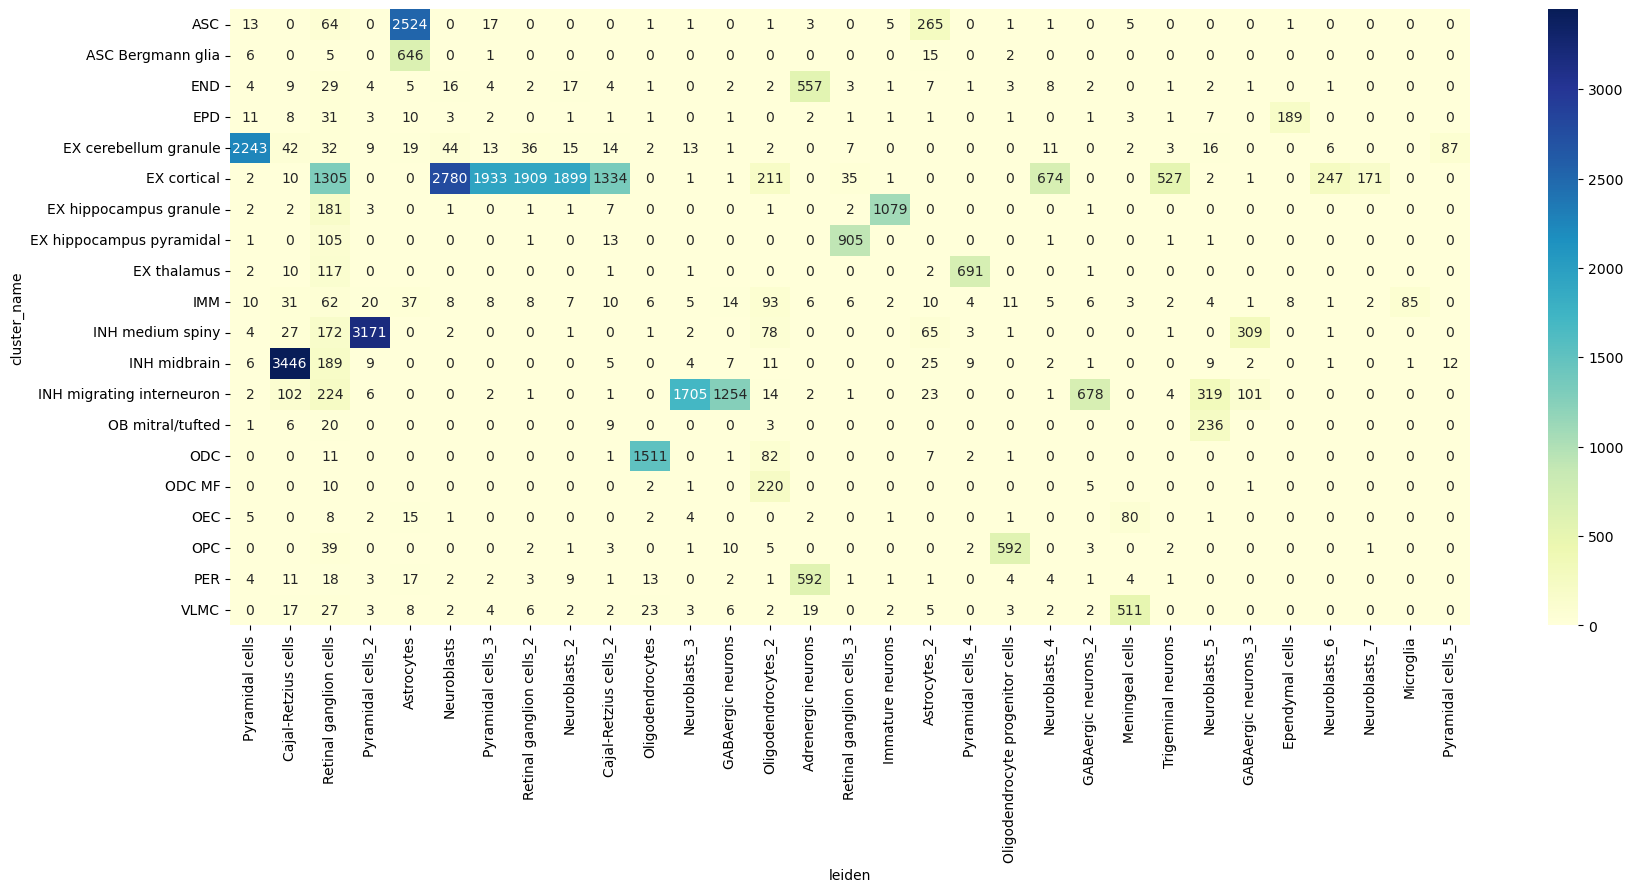

In [40]:
# check agreement between original cell type assignments and ours
temp = acomb.obs[~acomb.obs.cluster_name.isna()]
cont_table = pd.crosstab(temp['cluster_name'], temp['leiden'])

plt.figure(figsize=(20,8))
sns.heatmap(cont_table, annot=True, cmap='YlGnBu', fmt='d', cbar=True)

/gpfs/commons/home/daknowles/.conda/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored


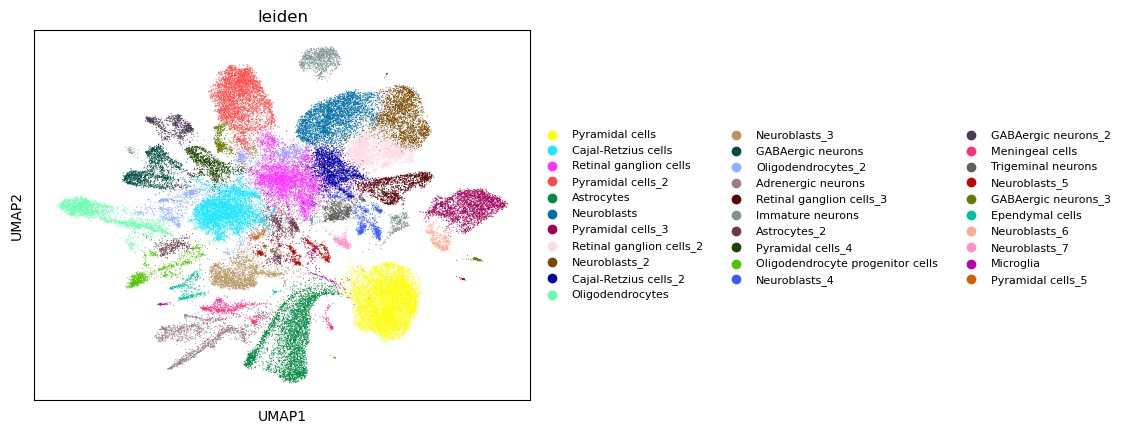

In [41]:
sc.pl.umap(acomb, color=['leiden'], legend_fontsize=8)